# 🧬 Cuaderno 02 Alineamiento de Secuencias

**Curso:** Bioinformática
**Repositorio:** `bio-notebooks`  
**Herramientas:** Python 3, matplotlib, numpy

---

## Competencias
- Comprender el problema del alineamiento de secuencias biológicas
- Implementar Needleman-Wunsch (alineamiento global) desde cero
- Implementar Smith-Waterman (alineamiento local) desde cero
- Interpretar matrices de puntuación y traceback

## Contenido
1. Marco teórico ¿por qué alinear secuencias?
2. Matrices de puntuación (match, mismatch, gap)
3. Needleman-Wunsch alineamiento global
4. Smith-Waterman alineamiento local
5. Visualización de matrices de scoring
6. Aplicación con secuencias reales de HBB humana y de gorila
7. Comparación NW vs SW
8. Preguntas de reflexión


## 1. Marco Teórico

### 1.1 ¿Por qué alinear secuencias?

El **alineamiento de secuencias** responde a una pregunta fundamental:  
*¿Qué tan similares son dos secuencias biológicas?*

Comparar secuencias permite:
- Identificar genes homólogos entre especies
- Predecir función de una secuencia desconocida
- Estudiar evolución molecular
- Detectar mutaciones patogénicas

### 1.2 Tipos de alineamiento

| Tipo | Algoritmo | Uso |
|---|---|---|
| **Global** | Needleman-Wunsch (1970) | Secuencias de longitud similar, homólogas en toda su extensión |
| **Local** | Smith-Waterman (1981) | Encontrar regiones similares dentro de secuencias más largas |

### 1.3 Componentes del alineamiento

Un alineamiento introduce **gaps** (`-`) para maximizar la similitud:

```
Secuencia 1:  ATGC-ATGC
Secuencia 2:  ATGCGATGC
              ||||.||||
```

### 1.4 Sistema de puntuación

Cada posición del alineamiento recibe una puntuación:

| Evento | Símbolo | Puntuación típica |
|---|---|---|
| Match (bases iguales) | `\|` | +2 |
| Mismatch (bases distintas) | `.` | -1 |
| Gap (inserción/deleción) | `-` | -2 |

La puntuación total es la **suma** de todas las posiciones.

### 1.5 Programación dinámica

Ambos algoritmos usan **programación dinámica** para evitar recalcular subproblemas.  
Llenan una matriz $H$ de tamaño $(n+1) \times (m+1)$ donde $n$ y $m$ son las longitudes de las secuencias.

**Recurrencia Needleman-Wunsch:**

$$H(i,j) = \max \begin{cases} H(i-1,j-1) + s(a_i, b_j) & \text{match/mismatch} \\ H(i-1,j) + g & \text{gap en seq2} \\ H(i,j-1) + g & \text{gap en seq1} \end{cases}$$

**Diferencia Smith-Waterman:**  
Igual pero con un cuarto caso: $\max(..., 0)$ nunca permite scores negativos, así encuentra la mejor región local.


## 2. Parámetros de Puntuación


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from dataclasses import dataclass

@dataclass
class ScoreParams:
    """
    Parámetros del sistema de puntuación.

    Atributos
    ---------
    match    : puntuación por bases iguales      (positivo)
    mismatch : penalización por bases distintas  (negativo)
    gap      : penalización por gap              (negativo)
    """
    match:    int = 2
    mismatch: int = -1
    gap:      int = -2

    def score(self, a: str, b: str) -> int:
        """Devuelve match o mismatch según si las bases son iguales."""
        return self.match if a.upper() == b.upper() else self.mismatch

# Parámetros por defecto
params = ScoreParams(match=2, mismatch=-1, gap=-2)
print(f"Match    : +{params.match}")
print(f"Mismatch :  {params.mismatch}")
print(f"Gap      :  {params.gap}")
print(f"\nEjemplo: score('A','A') = {params.score('A','A')}")
print(f"Ejemplo: score('A','T') = {params.score('A','T')}")


Match    : +2
Mismatch :  -1
Gap      :  -2

Ejemplo: score('A','A') = 2
Ejemplo: score('A','T') = -1


## 3. Needleman-Wunsch Alineamiento Global

Alinea **toda** la longitud de ambas secuencias.  
Tiene dos fases:
1. **Llenado de la matriz** programación dinámica
2. **Traceback** reconstruir el alineamiento óptimo desde la esquina inferior derecha


In [14]:
@dataclass
class AlignmentResult:
    """Resultado de un alineamiento."""
    seq1_aligned: str
    seq2_aligned: str
    score:        int
    matrix:       np.ndarray
    algorithm:    str

    @property
    def identity(self) -> float:
        """Porcentaje de identidad: posiciones con match / longitud total."""
        matches = sum(a == b for a, b in zip(self.seq1_aligned, self.seq2_aligned)
                      if a != '-' and b != '-')
        length  = max(len(self.seq1_aligned), len(self.seq2_aligned))
        return matches / length * 100 if length > 0 else 0.0

    @property
    def alignment_str(self) -> str:
        """Representación visual del alineamiento"""
        middle = ''
        for a, b in zip(self.seq1_aligned, self.seq2_aligned):
            if a == '-' or b == '-':
                middle += ' '
            elif a.upper() == b.upper():
                middle += '|'
            else:
                middle += '.'
        return (f"Seq1: {self.seq1_aligned}\n"
                f"      {middle}\n"
                f"Seq2: {self.seq2_aligned}")

    def __repr__(self):
        return (f"AlignmentResult(algorithm={self.algorithm!r}, "
                f"score={self.score}, identity={self.identity:.1f}%)")


class NeedlemanWunsch:
    """
    Alineamiento global usando el algoritmo de Needleman-Wunsch (1970).

    Complejidad: O(n × m) tiempo y espacio.
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        """
        Alinea seq1 y seq2 globalmente.

        Parámetros
        ----------
        seq1, seq2 : cadenas de nucleótidos

        Retorna
        -------
        AlignmentResult con las secuencias alineadas y la matriz de scoring
        """
        n, m = len(seq1), len(seq2)
        H    = np.zeros((n + 1, m + 1), dtype=int)

        #Inicialización primera fila y columna con gaps
        for i in range(n + 1):
            H[i][0] = i * self.params.gap
        for j in range(m + 1):
            H[0][j] = j * self.params.gap

        #Llenado de la matriz
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diagonal = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                arriba   = H[i-1][j]   + self.params.gap
                izquierda= H[i][j-1]   + self.params.gap
                H[i][j]  = max(diagonal, arriba, izquierda)

        #Traceback desde (n, m) hasta (0, 0)
        aln1, aln2 = '', ''
        i, j = n, m
        while i > 0 or j > 0:
            if i > 0 and j > 0 and (
                H[i][j] == H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
            ):
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif i > 0 and H[i][j] == H[i-1][j] + self.params.gap:
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, int(H[n][m]), H, "Needleman-Wunsch")


#Prueba con secuencias cortas
seq_a = "ATGCATGC"
seq_b = "ATGGATGC"

nw     = NeedlemanWunsch(params)
result = nw.align(seq_a, seq_b)

print(f"Algoritmo : {result.algorithm}")
print(f"Score     : {result.score}")
print(f"Identidad : {result.identity:.1f}%")
print(f"\n{result.alignment_str}")


Algoritmo : Needleman-Wunsch
Score     : 13
Identidad : 87.5%

Seq1: ATGCATGC
      |||.||||
Seq2: ATGGATGC


## 4. Smith-Waterman Alineamiento Local

La diferencia clave con NW es que **nunca permite valores negativos** en la matriz.  
El traceback empieza desde la **celda de mayor valor** (no la esquina), y termina cuando llega a 0.  
Esto permite encontrar la región de mayor similitud dentro de secuencias más largas.


In [15]:
class SmithWaterman:
    """
    Alineamiento local usando el algoritmo de Smith-Waterman (1981).

    Complejidad: O(n × m) tiempo y espacio.
    Diferencia vs NW: H[i][j] = max(..., 0)
                      Traceback desde max(H), termina en 0.
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        n, m = len(seq1), len(seq2)
        H    = np.zeros((n + 1, m + 1), dtype=int)

        # Llenado igual que NW pero con max(..., 0)
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diagonal  = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                arriba    = H[i-1][j]   + self.params.gap
                izquierda = H[i][j-1]   + self.params.gap
                H[i][j]   = max(diagonal, arriba, izquierda, 0)  # diferencia mas importante

        # Traceback desde la celda de mayor valor
        i, j  = np.unravel_index(np.argmax(H), H.shape)
        score = int(H[i][j])
        aln1, aln2 = '', ''

        while i > 0 and j > 0 and H[i][j] > 0:
            if H[i][j] == H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1]):
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif H[i][j] == H[i-1][j] + self.params.gap:
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, score, H, "Smith-Waterman")


# Prueba con las mismas secuencias
sw     = SmithWaterman(params)
result_sw = sw.align(seq_a, seq_b)

print(f"Algoritmo : {result_sw.algorithm}")
print(f"Score     : {result_sw.score}")
print(f"Identidad : {result_sw.identity:.1f}%")
print(f"\n{result_sw.alignment_str}")


Algoritmo : Smith-Waterman
Score     : 13
Identidad : 87.5%

Seq1: ATGCATGC
      |||.||||
Seq2: ATGGATGC


## 5. Visualización de Matrices de Scoring

Las matrices de scoring muestran cómo se acumulan los puntajes.  
Las celdas más brillantes indican regiones de mayor similitud.


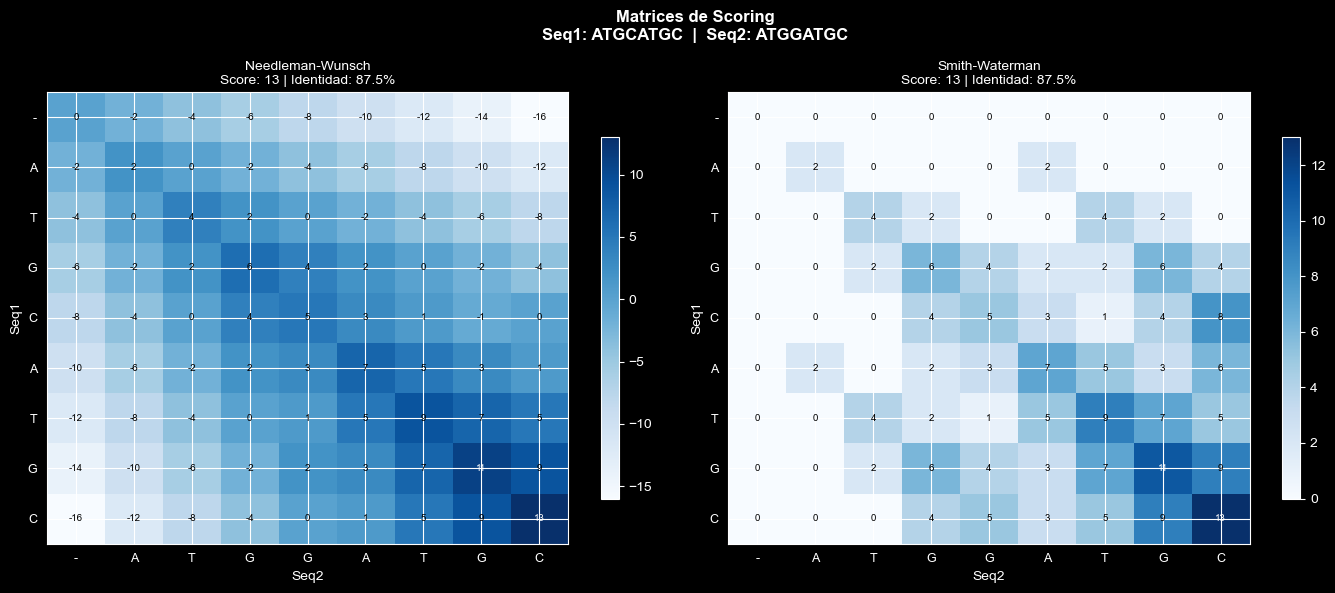

In [16]:
def plot_matrix(result: AlignmentResult, seq1: str, seq2: str, ax: plt.Axes):
    """Dibuja la matriz de scoring con heatmap."""
    H = result.matrix
    im = ax.imshow(H, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)

    ax.set_xticks(range(len(seq2) + 1))
    ax.set_xticklabels(['-'] + list(seq2), fontsize=9)
    ax.set_yticks(range(len(seq1) + 1))
    ax.set_yticklabels(['-'] + list(seq1), fontsize=9)

    # Valores en cada celda
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            ax.text(j, i, str(H[i, j]), ha='center', va='center',
                    fontsize=7, color='black' if H[i,j] < H.max()*0.7 else 'white')

    ax.set_title(f"{result.algorithm}\nScore: {result.score} | "
                 f"Identidad: {result.identity:.1f}%", fontsize=10)
    ax.set_xlabel("Seq2")
    ax.set_ylabel("Seq1")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Matrices de Scoring\nSeq1: {seq_a}  |  Seq2: {seq_b}",
             fontsize=12, fontweight='bold')

nw_result = NeedlemanWunsch(params).align(seq_a, seq_b)
sw_result = SmithWaterman(params).align(seq_a, seq_b)

plot_matrix(nw_result, seq_a, seq_b, axes[0])
plot_matrix(sw_result, seq_a, seq_b, axes[1])

plt.tight_layout()
plt.show()


## 6. Aplicación con Secuencias Reales

Comparamos los primeros 50 nucleótidos del gen **HBB** (hemoglobina beta) de:
- *Homo sapiens* (humano) NM_000518.5
- *Gorilla gorilla* (gorila) secuencia representativa

Esta comparación ilustra cómo el alineamiento detecta conservación evolutiva.  
Se espera alta identidad porque divergieron hace ~7-10 millones de años.


In [17]:
# Primeros 50 nt del CDS de HBB humana (NM_000518.5, región codificante)
hbb_human  = "ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGG"

# HBB gorila alta conservación esperada (~98% identidad)
# Diferencias conocidas en posiciones 2, 25, 43 (cambios sinónimos)
hbb_gorila = "ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCGGTTACTGCCCTGTGGG"

print("Secuencias a alinear:")
print(f"HBB Humano : {hbb_human}")
print(f"HBB Gorila : {hbb_gorila}")
print(f"\nLongitudes: {len(hbb_human)} bp vs {len(hbb_gorila)} bp")

# Diferencias manuales
diffs = sum(a != b for a, b in zip(hbb_human, hbb_gorila))
print(f"Diferencias visibles: {diffs} posiciones")


Secuencias a alinear:
HBB Humano : ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGG
HBB Gorila : ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCGGTTACTGCCCTGTGGG

Longitudes: 49 bp vs 49 bp
Diferencias visibles: 1 posiciones


In [18]:
# Alineamiento global (NW) apropiado porque son secuencias de la misma longitud
nw      = NeedlemanWunsch(params)
res_nw  = nw.align(hbb_human, hbb_gorila)

print("=" * 60)
print("NEEDLEMAN-WUNSCH (Global)")
print("=" * 60)
print(f"Score     : {res_nw.score}")
print(f"Identidad : {res_nw.identity:.1f}%")
print(f"\n{res_nw.alignment_str}")

# Alineamiento local (SW)
sw      = SmithWaterman(params)
res_sw  = sw.align(hbb_human, hbb_gorila)

print("\n" + "=" * 60)
print("SMITH-WATERMAN (Local)")
print("=" * 60)
print(f"Score     : {res_sw.score}")
print(f"Identidad : {res_sw.identity:.1f}%")
print(f"\n{res_sw.alignment_str}")


NEEDLEMAN-WUNSCH (Global)
Score     : 95
Identidad : 98.0%

Seq1: ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGG
      ||||||||||||||||||||||||||||||||.||||||||||||||||
Seq2: ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCGGTTACTGCCCTGTGGG

SMITH-WATERMAN (Local)
Score     : 95
Identidad : 98.0%

Seq1: ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGG
      ||||||||||||||||||||||||||||||||.||||||||||||||||
Seq2: ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCGGTTACTGCCCTGTGGG


## 7. Comparativa NW vs SW ¿Cuándo usar cada uno?


In [25]:
# Caso donde SW es claramente mejo,: una secuencia corta dentro de una larga
seq_corta = "GCATGC"
seq_larga = "AAAAAGCATGCTTTTTTTT"

nw_caso2  = NeedlemanWunsch(params).align(seq_corta, seq_larga)
sw_caso2  = SmithWaterman(params).align(seq_corta, seq_larga)

print("Secuencia corta:", seq_corta)
print("Secuencia larga:", seq_larga)
print()
print("NW (global) forzado a alinear todo, introduce gaps innecesarios:")
print(f"  Score: {nw_caso2.score}")
print(f"   {nw_caso2.alignment_str}")
print()
print("SW (local) encuentra la región de máxima similitud:")
print(f"   Score: {sw_caso2.score}")
print(f"  {sw_caso2.alignment_str}")


Secuencia corta: GCATGC
Secuencia larga: AAAAAGCATGCTTTTTTTT

NW (global) forzado a alinear todo, introduce gaps innecesarios:
  Score: -14
   Seq1: -----GCATGC--------
           ||||||        
Seq2: AAAAAGCATGCTTTTTTTT

SW (local) encuentra la región de máxima similitud:
   Score: 12
  Seq1: GCATGC
      ||||||
Seq2: GCATGC


## 8. Secuencias Reales Descarga desde NCBI

Descargamos directamente desde NCBI usando **Biopython** (`Entrez`):
- **BRCA1 humano** (U14680.1) gen de reparación de ADN, asociado a cáncer de mama
- **BRCA1 ratón** (NM_009764) homólogo en *Mus musculus*

Comparar BRCA1 entre humano y ratón es un caso clásico: divergieron hace ~87 millones de años
pero el gen está muy conservado porque es esencial para la reparación del ADN.


In [26]:
from Bio import Entrez, SeqIO
import time

#️ Reemplaza con tu email real NCBI lo requiere para Entrez
Entrez.email = "tu_email@example.com"

def descargar_secuencia(accession: str, rettype: str = "fasta") -> str:
    """
    Descarga una secuencia de NCBI y retorna solo los nucleótidos.

    Parámetros
    ----------
    accession : código de acceso NCBI (ej. 'U14680.1')
    rettype   : formato de retorno ('fasta' o 'gb')

    Retorna
    -------
    str con la secuencia de nucleótidos en mayúsculas
    """
    print(f"  Descargando {accession}...", end=" ", flush=True)
    handle = Entrez.efetch(
        db="nucleotide",
        id=accession,
        rettype=rettype,
        retmode="text"
    )
    record = SeqIO.read(handle, rettype)
    handle.close()
    time.sleep(0.4)   # respetar límite de NCBI: max 3 req/seg
    print(f" {len(record.seq):,} bp")
    return str(record.seq).upper()

print("Descargando secuencias desde NCBI...")
brca1_human = descargar_secuencia("U14680.1")
brca1_mouse = descargar_secuencia("NM_009764")

print(f"\nBRCA1 humano : {len(brca1_human):,} bp")
print(f"BRCA1 ratón  : {len(brca1_mouse):,} bp")


Descargando secuencias desde NCBI...
  Descargando U14680.1...  5,711 bp
  Descargando NM_009764...  6,648 bp

BRCA1 humano : 5,711 bp
BRCA1 ratón  : 6,648 bp


> **Nota:** Si no tienes conexión o Biopython no está instalado, el bloque siguiente
> usa los primeros 200 nt de cada gen directamente como cadena el algoritmo funciona igual.


In [21]:
# Fallback manual primeros 200 nt representativos si la descarga falla
# Fuente: NCBI U14680.1 y NM_009764 (regiones de exón 2)
try:
    # Usar solo los primeros 200 nt para que la matriz sea visualizable
    seq_brca1_h = brca1_human[:200]
    seq_brca1_m = brca1_mouse[:200]
    print("Usando secuencias descargadas (primeros 200 nt)")
except NameError:
    seq_brca1_h = ("ATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTATGCAGAAAATCTTAGA"
                   "GTGTCCCATCTGTCTGGAGTTGATCAAGGAACCTGTCTCCACAAAGTGTGACCACATATTTTGCAAAT"
                   "TTTGCATGCTGAAACTTCTCAACCAGAAGAAAGGGCCTTCACAGTGTCCTTTATGTAAGAATGATATA")
    seq_brca1_m = ("ATGGATTTATCTGCTCTTCGCATTGAAGAAGTACAAAATGTCGTTAATGCTATGCAGAAAATCTTAGA"
                   "GTGTCCCATCTGTCTGGAGTTGATCAAGGAGCCTGTCTCCACGAAGTGTGACCACATATTTTGCAAAT"
                   "TTTGCATGCTGAAACTTCTCAACCAGAAGAAAGGGCCTTCACAGTGTCCTCTATGTAAGAATGATATA")
    print("Usando secuencias de fallback (200 nt)")

print(f"\nSeq BRCA1 humano ({len(seq_brca1_h)} nt): {seq_brca1_h[:40]}...")
print(f"Seq BRCA1 ratón  ({len(seq_brca1_m)} nt): {seq_brca1_m[:40]}...")


Usando secuencias descargadas (primeros 200 nt)

Seq BRCA1 humano (200 nt): AGCTCGCTGAGACTTCCTGGACCCCGCACCAGGCTGTGGG...
Seq BRCA1 ratón  (200 nt): GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTC...


### Alineamiento SW sobre secuencias reales + medición de tiempo (Ejercicio 5)


In [22]:
import time

# Alineamiento con parámetros del laboratorio: match=+2, mismatch=-1, gap=-2
params_lab = ScoreParams(match=2, mismatch=-1, gap=-2)
sw_real    = SmithWaterman(params_lab)

print("Ejecutando Smith-Waterman sobre BRCA1 humano vs ratón...")
t0         = time.perf_counter()
res_real   = sw_real.align(seq_brca1_h, seq_brca1_m)
elapsed    = (time.perf_counter() - t0) * 1000

print(f"\n{'='*60}")
print(f"  BRCA1 Humano vs Ratón — Smith-Waterman")
print(f"{'='*60}")
print(f"  Score         : {res_real.score}")
print(f"  Identidad     : {res_real.identity:.1f}%")
print(f"  Long. aln     : {len(res_real.seq1_aligned)} nt")
print(f"  Tiempo        : {elapsed:.2f} ms  ({len(seq_brca1_h)}×{len(seq_brca1_m)} celdas)")
print(f"{'='*60}")
print(f"\n{res_real.alignment_str[:200]}...")

# Ejercicio 4: cambiar gap y comparar
print("\n" + "="*60)
print("  Ejercicio 4 — Gap diferente: -1 vs -2 vs -4")
print("="*60)
for gap_val in [-1, -2, -4]:
    p   = ScoreParams(match=2, mismatch=-1, gap=gap_val)
    res = SmithWaterman(p).align(seq_brca1_h, seq_brca1_m)
    print(f"  Gap={gap_val:2d} → Score={res.score:4d} | "
          f"Identidad={res.identity:5.1f}% | "
          f"Long. aln={len(res.seq1_aligned):3d} nt")
print()
print("  Interpretación:")
print("  - Gap menos negativo (-1): permite más gaps → alineamiento más largo")
print("  - Gap más negativo   (-4): penaliza gaps → alineamiento más corto y compacto")


Ejecutando Smith-Waterman sobre BRCA1 humano vs ratón...

  BRCA1 Humano vs Ratón — Smith-Waterman
  Score         : 90
  Identidad     : 53.9%
  Long. aln     : 193 nt
  Tiempo        : 131.08 ms  (200×200 celdas)

Seq1: AGCTCGCTGAGACTTCCTGGACCCCGCACCAGGCTGTGGGGTTTCTCAGATAACTGGGCCCCTGC-GCTCAGGAGGCCTTCACCCTCTGCTCTGGGTAAAGTTCATTGGAACAGAAAGAAATGGATTTATCTGCTCTTC-GCG-TTGAAGAAGTACAAAATGTCATTAATGCTATGCAGAAAATCTTAGAGTG
...

  Ejercicio 4 — Gap diferente: -1 vs -2 vs -4
  Gap=-1 → Score= 145 | Identidad= 54.3% | Long. aln=230 nt
  Gap=-2 → Score=  90 | Identidad= 53.9% | Long. aln=193 nt
  Gap=-4 → Score=  61 | Identidad= 64.2% | Long. aln= 95 nt

  Interpretación:
  - Gap menos negativo (-1): permite más gaps → alineamiento más largo
  - Gap más negativo   (-4): penaliza gaps → alineamiento más corto y compacto


## 9. Heatmap con Camino del Traceback Resaltado (Ejercicio 6)

El **traceback** es la ruta que el algoritmo siguió para reconstruir el alineamiento óptimo.
En el heatmap:
- **Azul claro → azul oscuro**: score acumulado (más oscuro = mayor score)
- **Línea roja**: camino exacto del traceback — el alineamiento óptimo
- **Estrella ★**: punto de inicio del traceback (celda con score máximo)
- **Círculo ●**: punto final (donde el score llega a 0)


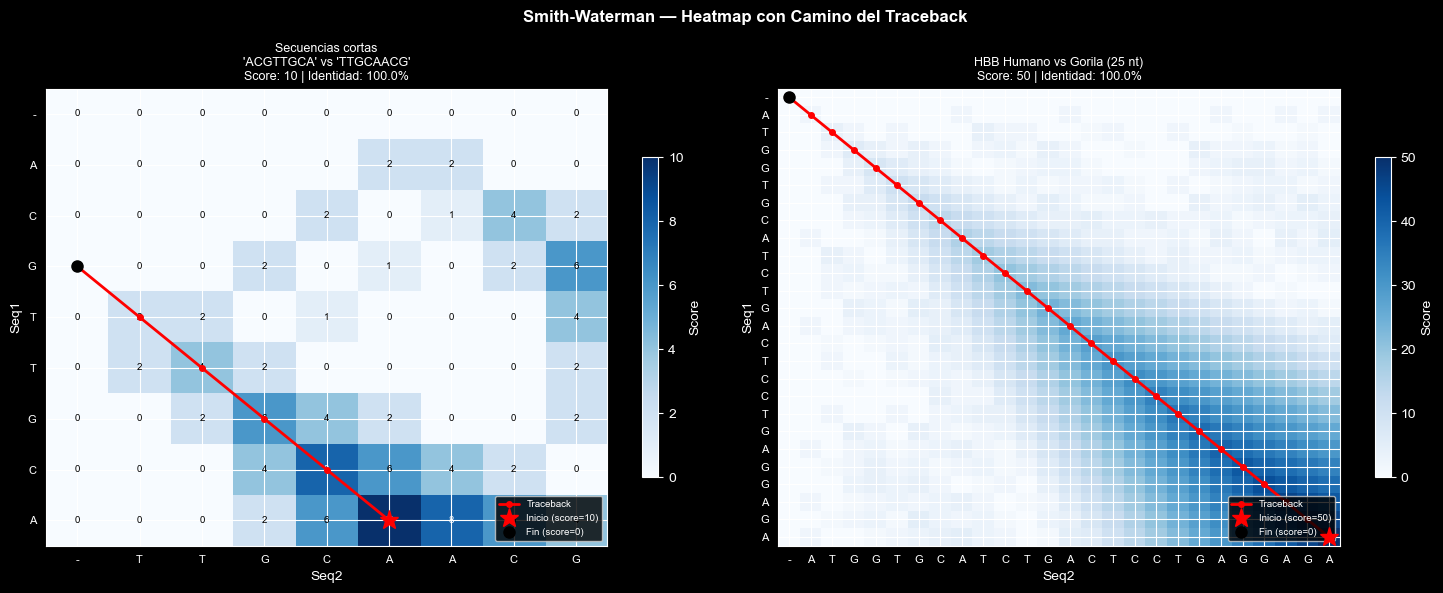


Interpretación del camino:
  La línea roja muestra exactamente qué decisión tomó el algoritmo
  en cada paso del traceback: diagonal=match/mismatch, arriba/izq=gap.
  Pasos totales en el traceback: N/A


In [23]:
def plot_traceback(result: AlignmentResult, seq1: str, seq2: str,
                   params: ScoreParams, ax: plt.Axes, title: str = ""):
    """
    Dibuja la matriz con el camino del traceback resaltado en rojo.
    Funciona mejor con secuencias cortas (< 30 nt) para que sea legible.
    """
    H = result.matrix

    # Reconstruir el camino del traceback
    path = []
    i, j = int(np.argmax(H) // H.shape[1]), int(np.argmax(H) % H.shape[1])
    path.append((i, j))

    while i > 0 and j > 0 and H[i][j] > 0:
        if H[i][j] == H[i-1][j-1] + params.score(seq1[i-1], seq2[j-1]):
            i -= 1; j -= 1
        elif H[i][j] == H[i-1][j] + params.gap:
            i -= 1
        else:
            j -= 1
        path.append((i, j))

    # Heatmap
    im = ax.imshow(H, cmap='Blues', aspect='auto', vmin=0)
    plt.colorbar(im, ax=ax, shrink=0.7, label='Score')

    # Etiquetas de ejes
    ax.set_xticks(range(len(seq2) + 1))
    ax.set_xticklabels(['-'] + list(seq2), fontsize=8)
    ax.set_yticks(range(len(seq1) + 1))
    ax.set_yticklabels(['-'] + list(seq1), fontsize=8)

    # Valores en celdas (solo si secuencia es corta)
    if len(seq1) <= 20 and len(seq2) <= 20:
        for ii in range(H.shape[0]):
            for jj in range(H.shape[1]):
                color = 'white' if H[ii,jj] > H.max()*0.6 else 'black'
                ax.text(jj, ii, str(H[ii,jj]),
                        ha='center', va='center', fontsize=7, color=color)

    # Dibujar camino del traceback
    if len(path) > 1:
        path_y = [p[0] for p in path]
        path_x = [p[1] for p in path]
        ax.plot(path_x, path_y, 'r-o', linewidth=2, markersize=4,
                label='Traceback', zorder=5)
        # Inicio (máximo)
        ax.plot(path_x[0], path_y[0], 'r*', markersize=14,
                label=f'Inicio (score={H[path_y[0], path_x[0]]})', zorder=6)
        # Final (cero)
        ax.plot(path_x[-1], path_y[-1], 'ko', markersize=8,
                label='Fin (score=0)', zorder=6)

    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlabel("Seq2")
    ax.set_ylabel("Seq1")
    ax.set_title(f"{title}\nScore: {result.score} | Identidad: {result.identity:.1f}%",
                 fontsize=9)


# Gráfica 1: secuencias cortas — matriz completamente legible
seq_corta1 = "ACGTTGCA"
seq_corta2 = "TTGCAACG"
res_corta  = SmithWaterman(params_lab).align(seq_corta1, seq_corta2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Smith-Waterman — Heatmap con Camino del Traceback",
             fontsize=12, fontweight='bold')

plot_traceback(res_corta, seq_corta1, seq_corta2, params_lab, axes[0],
               f"Secuencias cortas\n'{seq_corta1}' vs '{seq_corta2}'")

#Gráfica 2: HBB humano vs gorila (50 nt)
res_hbb50 = SmithWaterman(params_lab).align(hbb_human[:25], hbb_gorila[:25])
plot_traceback(res_hbb50, hbb_human[:25], hbb_gorila[:25], params_lab, axes[1],
               "HBB Humano vs Gorila (25 nt)")

plt.tight_layout()
plt.show()

print("\nInterpretación del camino:")
print("  La línea roja muestra exactamente qué decisión tomó el algoritmo")
print("  en cada paso del traceback: diagonal=match/mismatch, arriba/izq=gap.")
print(f"  Pasos totales en el traceback: {len(path) if 'path' in dir() else 'N/A'}")


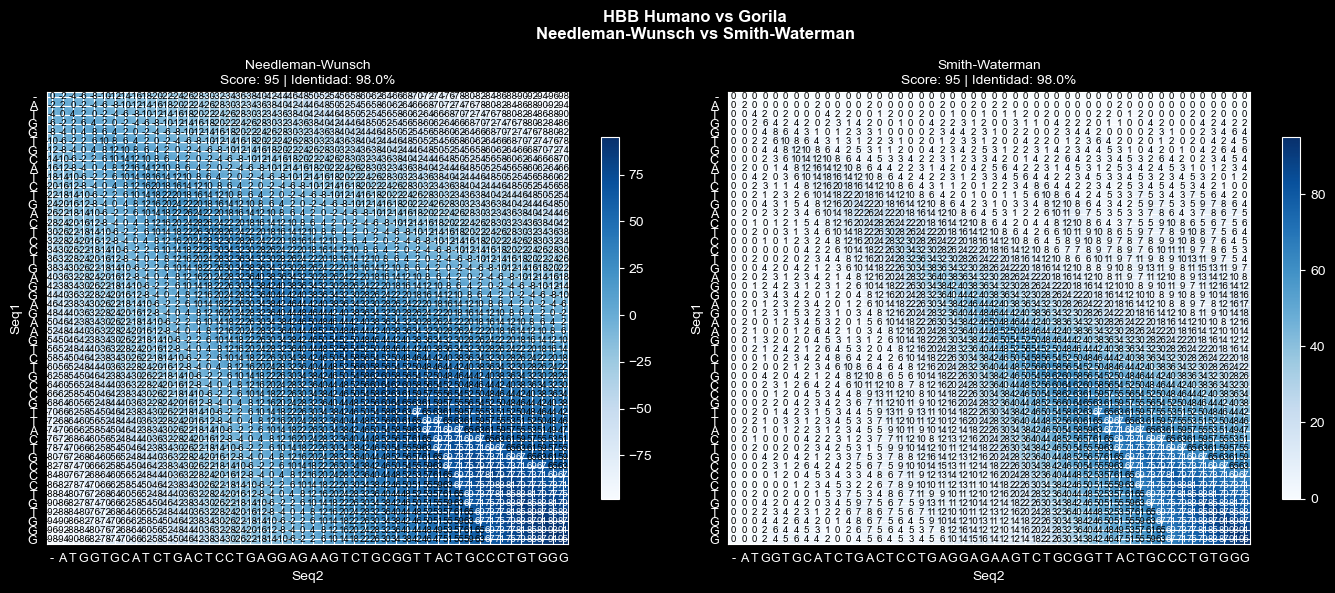


  Métrica                             NW           SW
  Score                               95           95
  Identidad (%)                    98.0%        98.0%
  Long. alineamiento                  49           49


In [24]:
# Gráfica comparativa de ambos resultados con HBB
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("HBB Humano vs Gorila\nNeedleman-Wunsch vs Smith-Waterman",
             fontsize=12, fontweight='bold')

plot_matrix(res_nw, hbb_human, hbb_gorila, axes[0])
plot_matrix(res_sw, hbb_human, hbb_gorila, axes[1])

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "="*55)
print(f"  {'Métrica':<25} {'NW':>12} {'SW':>12}")
print("="*55)
print(f"  {'Score':<25} {res_nw.score:>12} {res_sw.score:>12}")
print(f"  {'Identidad (%)':<25} {res_nw.identity:>11.1f}% {res_sw.identity:>11.1f}%")
print(f"  {'Long. alineamiento':<25} {len(res_nw.seq1_aligned):>12} {len(res_sw.seq1_aligned):>12}")
print("="*55)


## 8. Preguntas de Reflexión

1. **¿Por qué el alineamiento global (NW) puede dar un score menor que el local (SW) cuando las secuencias tienen longitudes muy diferentes?**  
   _Responde aquí..._

2. **Si aumentas la penalización de gap de -2 a -5, ¿qué efecto tendrá en el alineamiento? ¿Más o menos gaps?**  
   _Responde aquí..._

3. **La identidad entre HBB humano y gorila es alta. ¿Qué implicación biológica tiene eso?**  
   _Responde aquí..._

4. **¿Cuál es la complejidad temporal de NW y SW? ¿Sería factible alinear dos cromosomas completos (~200 Mbp cada uno)?**  
   _Responde aquí..._

5. **BLAST es mucho más rápido que SW para buscar en bases de datos. ¿Cómo lo logra? (investiga heurísticas)**  
   _Responde aquí..._

---

## 9. Conclusiones

- **Needleman-Wunsch** alinea secuencias completas ideal para homólogos de longitud similar
- **Smith-Waterman** encuentra la mejor región local ideal para buscar dominios o motivos
- Ambos usan **programación dinámica** O(n×m) exactos pero lentos para secuencias muy largas
- La alta identidad HBB humano/gorila refleja **conservación evolutiva** del gen
- En la práctica, BLAST usa heurísticas basadas en SW para escalar a genomas completos

---

## 10. Referencias

- Needleman, S.B. & Wunsch, C.D. (1970). *A general method applicable to the search for similarities in the amino acid sequence of two proteins.* Journal of Molecular Biology.
- Smith, T.F. & Waterman, M.S. (1981). *Identification of common molecular subsequences.* Journal of Molecular Biology.
- NCBI BLAST: https://blast.ncbi.nlm.nih.gov/
